# Zomato Restaurant Data Analysis

### Exploratory Data Analysis of Restaurant Ratings, Cuisines, Locations and Pricing

**Internship:** InternSpark
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, WordCloud
**Platform:** Google Colab


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("/content/zomato.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [4]:
df.shape

(56252, 13)

In [5]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [7]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
dish_liked,50.175994
rate,13.933727
listed_in(type),8.195264
phone,2.303918
approx_cost(for two people),0.926189
rest_type,0.600868
cuisines,0.360876
location,0.223992
votes,0.138662
book_table,0.103107


In [9]:
df = df.drop(columns=["phone"])

print("Phone column removed")

Phone column removed


In [10]:
categorical_columns = [
    "location",
    "rest_type",
    "dish_liked",
    "cuisines",
    "listed_in(type)"
]

for column in categorical_columns:
    df[column] = df[column].fillna("Unknown")

print("Categorical missing values filled")

Categorical missing values filled


In [11]:
df["rate"] = df["rate"].astype(str).str.replace("/5", "", regex=False)
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

print("Rate column cleaned")

Rate column cleaned


In [12]:
df["approx_cost(for two people)"] = (
    df["approx_cost(for two people)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"],
    errors="coerce"
)

print("Cost column cleaned")

Cost column cleaned


In [13]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 20767


In [14]:
df = df.drop_duplicates()

print("Duplicate rows removed")
print("New dataset shape:", df.shape)

Duplicate rows removed
New dataset shape: (35485, 12)


In [15]:
df.isnull().sum()

,0
address,2
name,1
online_order,4
book_table,38
rate,9062
votes,58
location,0
rest_type,0
dish_liked,0
cuisines,0


In [16]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

,0
rate,9062
approx_cost(for two people),4328
votes,58
book_table,38
online_order,4
address,2
name,1


In [17]:
df["votes"] = pd.to_numeric(df["votes"], errors="coerce")
df["votes"] = df["votes"].fillna(0)

print("Missing votes values filled")

Missing votes values filled


In [18]:
df["book_table"] = df["book_table"].fillna("Unknown")

print("Missing book_table values filled")

Missing book_table values filled


In [19]:
df.isnull().sum()

,0
address,2
name,1
online_order,4
book_table,0
rate,9062
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0


In [20]:
df["name"] = df["name"].fillna("Unknown")

print("Missing restaurant names filled")

Missing restaurant names filled


In [21]:
df["address"] = df["address"].fillna("Unknown")

print("Missing address values filled")

Missing address values filled


In [22]:
df.isnull().sum()

,0
address,0
name,0
online_order,4
book_table,0
rate,9062
votes,0
location,0
rest_type,0
dish_liked,0
cuisines,0


In [23]:
df["online_order"] = df["online_order"].fillna("Unknown")

print("Missing online_order values filled")

Missing online_order values filled


In [24]:
valid_ratings = df["rate"].notna().sum()
missing_ratings = df["rate"].isna().sum()

print("Valid ratings:", valid_ratings)
print("Missing ratings:", missing_ratings)

Valid ratings: 26423
Missing ratings: 9062


In [25]:
valid_cost = df["approx_cost(for two people)"].notna().sum()
missing_cost = df["approx_cost(for two people)"].isna().sum()

print("Valid cost values:", valid_cost)
print("Missing cost values:", missing_cost)

Valid cost values: 31157
Missing cost values: 4328


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35485 entries, 0 to 56251
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      35485 non-null  object 
 1   name                         35485 non-null  object 
 2   online_order                 35485 non-null  object 
 3   book_table                   35485 non-null  object 
 4   rate                         26423 non-null  float64
 5   votes                        35485 non-null  float64
 6   location                     35485 non-null  object 
 7   rest_type                    35485 non-null  object 
 8   dish_liked                   35485 non-null  object 
 9   cuisines                     35485 non-null  object 
 10  approx_cost(for two people)  31157 non-null  float64
 11  listed_in(type)              35485 non-null  object 
dtypes: float64(3), object(9)
memory usage: 3.5+ MB


In [27]:
df.shape

(35485, 12)

In [28]:
df.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775.0,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787.0,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918.0,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88.0,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166.0,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Buffet


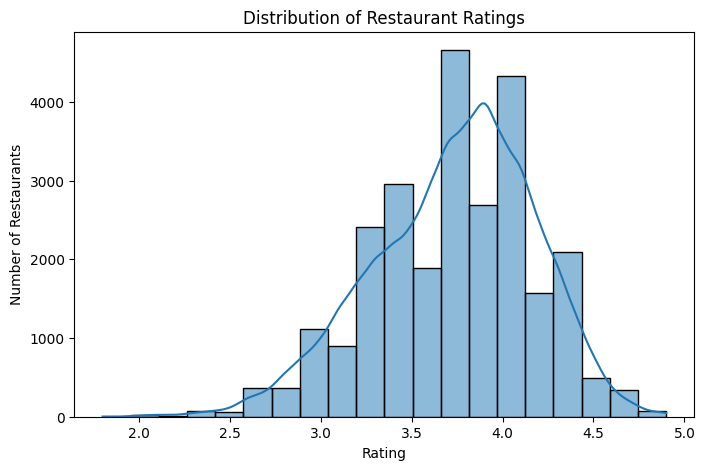

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["rate"].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

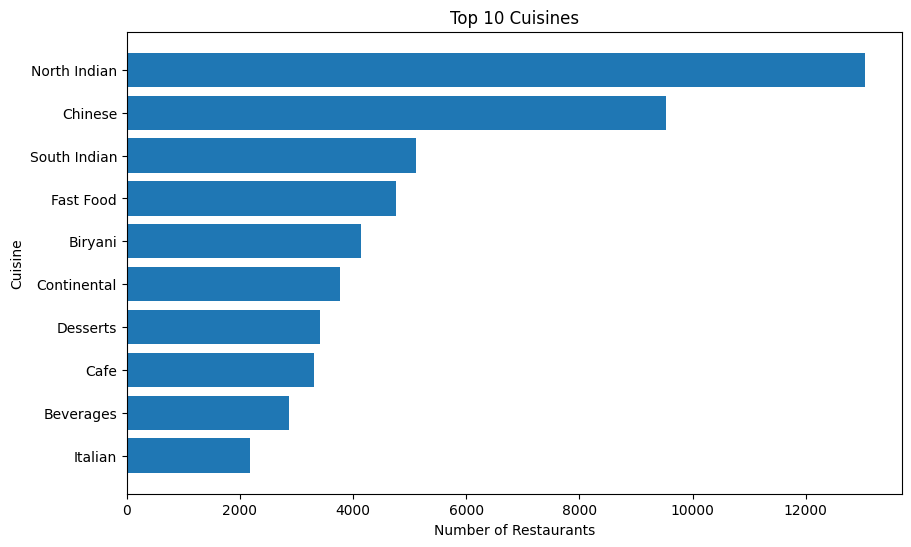

In [32]:
cuisines = df["cuisines"].str.split(", ").explode()
top_cuisines = cuisines.value_counts().head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_cuisines.index, top_cuisines.values)

plt.title("Top 10 Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.gca().invert_yaxis()
plt.show()

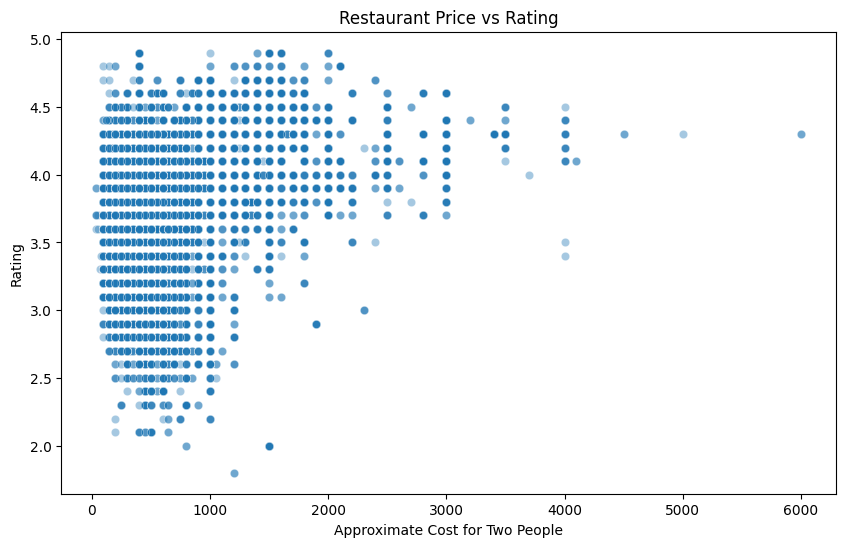

In [33]:
price_rating = df.dropna(
    subset=["approx_cost(for two people)", "rate"]
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=price_rating,
    x="approx_cost(for two people)",
    y="rate",
    alpha=0.4
)

plt.title("Restaurant Price vs Rating")
plt.xlabel("Approximate Cost for Two People")
plt.ylabel("Rating")

plt.show()

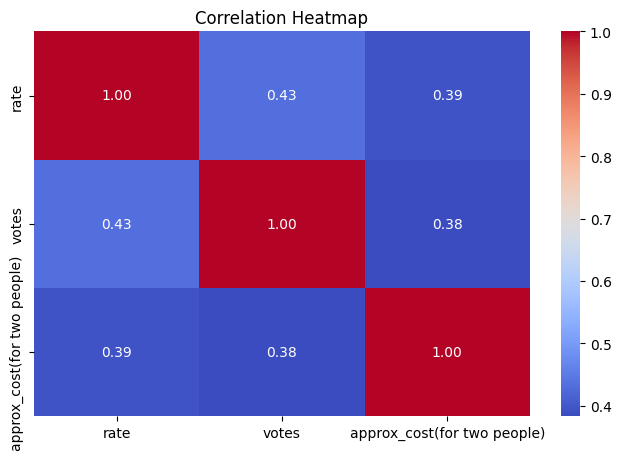

In [34]:
numeric_data = df[
    ["rate", "votes", "approx_cost(for two people)"]
].copy()

correlation = numeric_data.corr()

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [35]:
!pip install wordcloud

In [36]:
from wordcloud import WordCloud

dish_text = " ".join(
    df["dish_liked"]
    .dropna()
    .astype(str)
)

print("WordCloud data prepared")

WordCloud data prepared


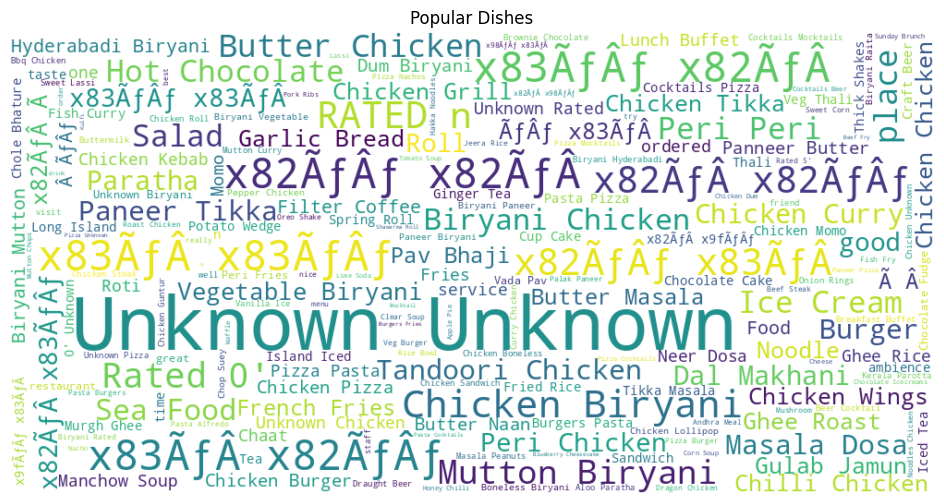

In [37]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(dish_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Popular Dishes")
plt.show()

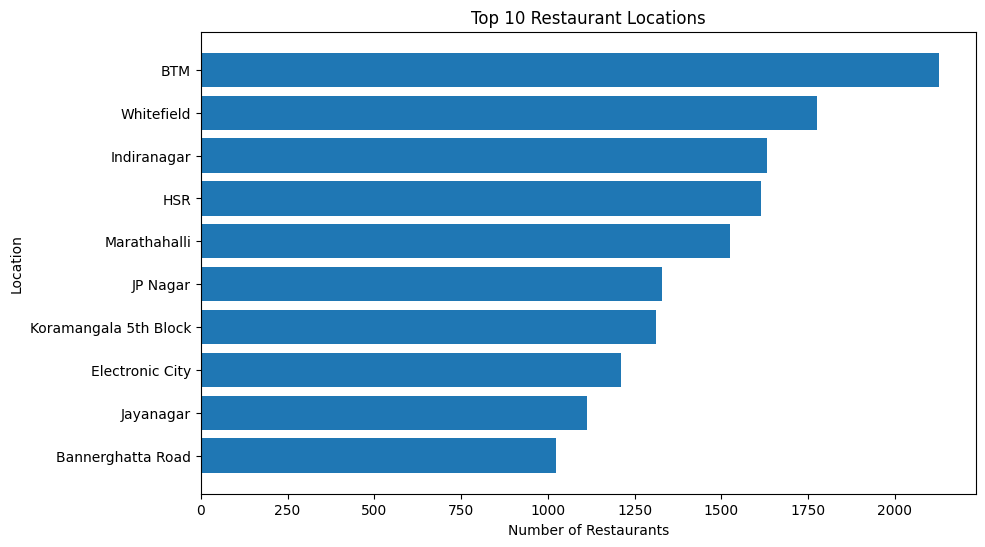

In [38]:
top_locations = df["location"].value_counts().head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_locations.index, top_locations.values)

plt.title("Top 10 Restaurant Locations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")

plt.gca().invert_yaxis()
plt.show()

In [39]:
df[["rate", "votes", "approx_cost(for two people)"]].describe()

,rate,votes,approx_cost(for two people)
count,26423.000000,35485.000000,31157.000000
mean,3.733880,296.385938,588.114324
std,0.446546,810.473642,459.340024
min,1.800000,0.000000,40.000000
25%,3.400000,0.000000,300.000000
50%,3.800000,41.000000,450.000000
75%,4.100000,217.000000,700.000000
max,4.900000,16832.000000,6000.000000


In [42]:
df["rate"] = df["rate"].astype(str).str.extract(r"(\d+\.?\d*)")[0]
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

print(df["rate"].head())
print("Rate column cleaned successfully")

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64
Rate column cleaned successfully


In [44]:
df["rate"] = df["rate"].astype(str)

df["rate"] = df["rate"].str.extract(r"^(\d+(?:\.\d+)?)")[0]

df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

print(df["rate"].dropna().head(10))
print("Rate column fixed")

0     4.1
1     4.1
2     3.8
3     3.7
4     3.8
5     3.8
6     3.6
7     4.6
8     4.0
10    4.2
Name: rate, dtype: float64
Rate column fixed


In [45]:
print(df["rate"].dtype)
print(df["rate"].dropna().head(10))
print("Missing ratings:", df["rate"].isna().sum())


float64
0     4.1
1     4.1
2     3.8
3     3.7
4     3.8
5     3.8
6     3.6
7     4.6
8     4.0
10    4.2
Name: rate, dtype: float64
Missing ratings: 9062


In [48]:
df["online_order"] = df["online_order"].where(
    df["online_order"].isin(["Yes", "No"]),
    np.nan
)

print(df["online_order"].value_counts(dropna=False))

online_order
Yes    18900
No     12447
NaN     4138
Name: count, dtype: int64


In [49]:
online_rating = df.groupby("online_order")["rate"].mean().round(2)

print("Average Rating by Online Ordering")
print(online_rating)

Average Rating by Online Ordering
online_order
No     3.71
Yes    3.75
Name: rate, dtype: float64


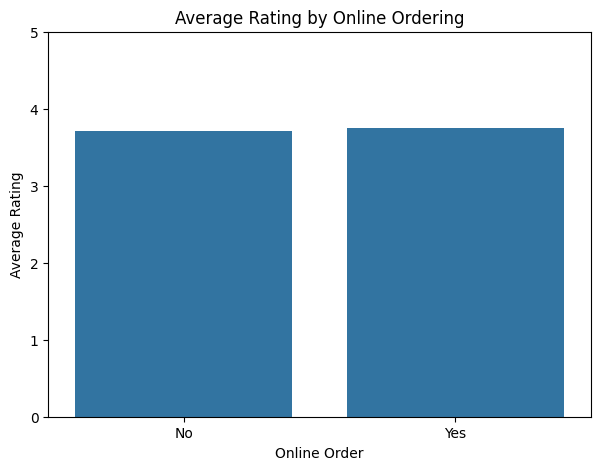

In [50]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=online_rating.index,
    y=online_rating.values
)

plt.title("Average Rating by Online Ordering")
plt.xlabel("Online Order")
plt.ylabel("Average Rating")
plt.ylim(0, 5)

plt.show()

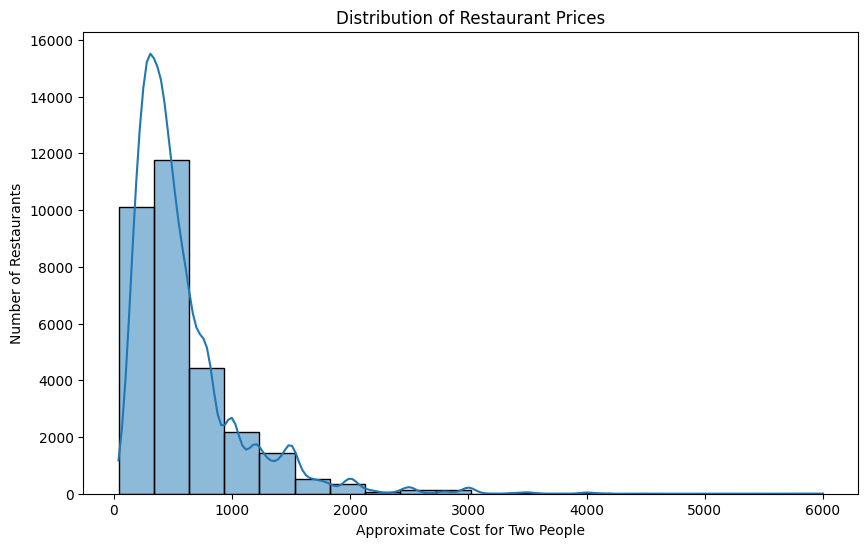

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["approx_cost(for two people)"].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of Restaurant Prices")
plt.xlabel("Approximate Cost for Two People")
plt.ylabel("Number of Restaurants")

plt.show()

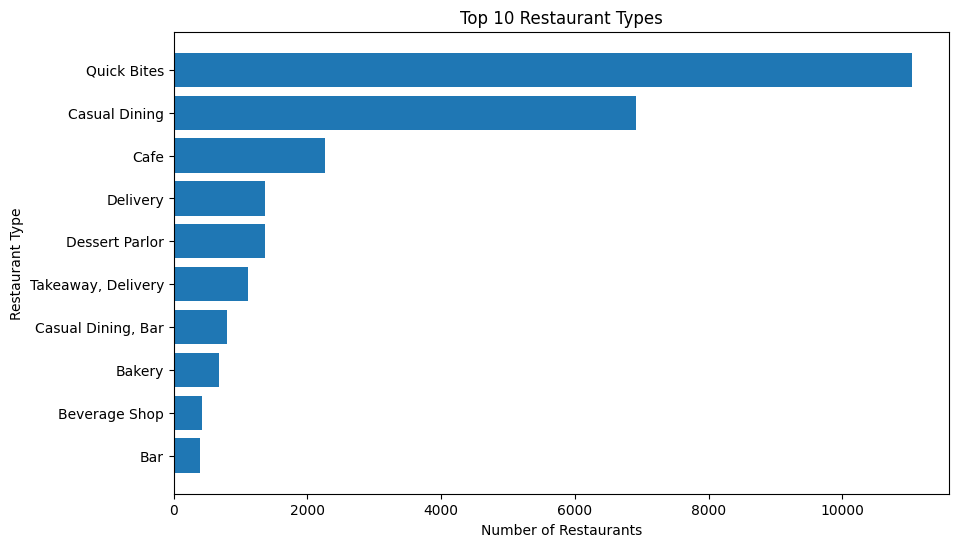

In [54]:
top_rest_types = df["rest_type"].value_counts().head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_rest_types.index, top_rest_types.values)

plt.title("Top 10 Restaurant Types")
plt.xlabel("Number of Restaurants")
plt.ylabel("Restaurant Type")

plt.gca().invert_yaxis()

plt.show()


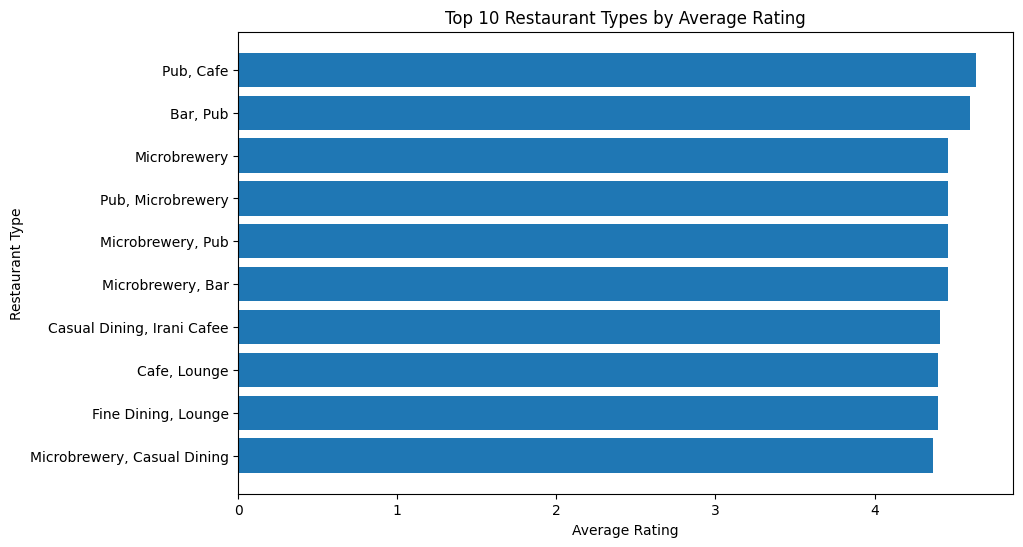

In [55]:
type_rating = df.groupby("rest_type")["rate"].mean().sort_values(ascending=False).head(10).round(2)

plt.figure(figsize=(10, 6))

plt.barh(type_rating.index, type_rating.values)

plt.title("Top 10 Restaurant Types by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant Type")

plt.gca().invert_yaxis()

plt.show()

In [56]:
cuisine_rating = df.copy()

cuisine_rating["cuisines"] = cuisine_rating["cuisines"].astype(str)

cuisine_data = cuisine_rating[
    cuisine_rating["rate"].notna() &
    (cuisine_rating["cuisines"] != "Unknown")
]

cuisine_data = cuisine_data.assign(
    cuisine=cuisine_data["cuisines"].str.split(", ")
).explode("cuisine")

top_cuisine_ratings = (
    cuisine_data.groupby("cuisine")["rate"]
    .agg(["mean", "count"])
    .query("count >= 50")
    .sort_values("mean", ascending=False)
    .head(10)
    .round(2)
)

print(top_cuisine_ratings)

               mean  count
cuisine                   
Modern Indian  4.33    103
Malaysian      4.30     69
Japanese       4.25    223
Mediterranean  4.25    368
European       4.21    477
Korean         4.19     97
Asian          4.17    822
Konkan         4.15     60
Indonesian     4.11     61
Steak          4.11    377


In [57]:
location_rating = (
    df[df["rate"].notna() & (df["location"] != "Unknown")]
    .groupby("location")["rate"]
    .agg(["mean", "count"])
    .query("count >= 50")
    .sort_values("mean", ascending=False)
    .head(10)
    .round(2)
)

print(location_rating)

                       mean  count
location                          
Lavelle Road           4.19    318
Koramangala 5th Block  4.10   1262
St. Marks Road         4.08    193
Koramangala 3rd Block  4.08     91
Church Street          4.04    364
Koramangala 4th Block  4.01    438
Cunningham Road        3.98    231
Residency Road         3.98    348
MG Road                3.96    471
Koramangala 7th Block  3.96    480


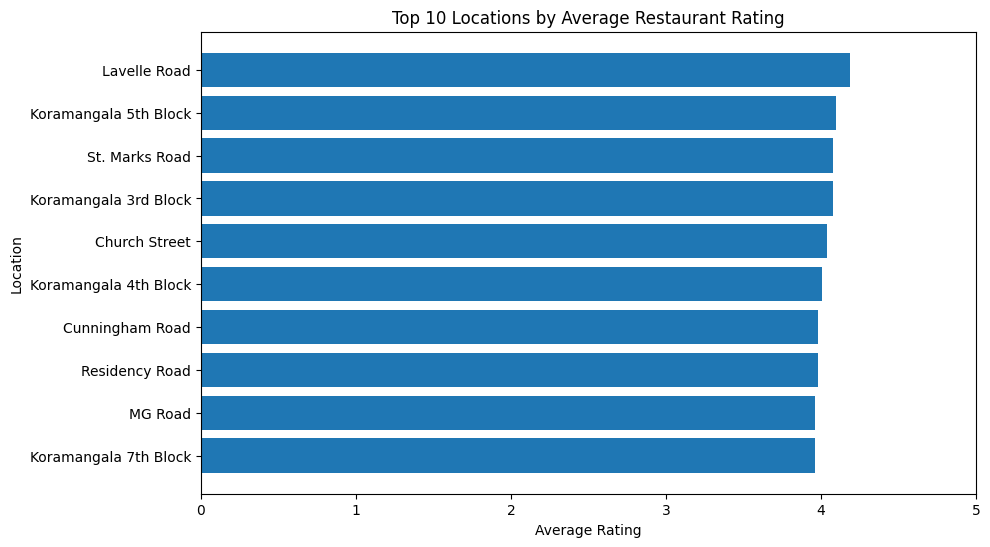

In [58]:
plt.figure(figsize=(10, 6))

plt.barh(
    location_rating.index,
    location_rating["mean"]
)

plt.title("Top 10 Locations by Average Restaurant Rating")
plt.xlabel("Average Rating")
plt.ylabel("Location")
plt.xlim(0, 5)

plt.gca().invert_yaxis()

plt.show()

In [59]:
print("Total Restaurants:", len(df))
print("Average Rating:", round(df["rate"].mean(), 2))
print("Highest Rating:", df["rate"].max())
print("Lowest Rating:", df["rate"].min())
print("Average Cost for Two:", round(df["approx_cost(for two people)"].mean(), 2))
print("Total Votes:", pd.to_numeric(df["votes"], errors="coerce").sum())

Total Restaurants: 35485
Average Rating: 3.73
Highest Rating: 4.9
Lowest Rating: 1.8
Average Cost for Two: 588.11
Total Votes: 10517255.0


In [60]:
cuisine_counts = (
    df["cuisines"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(5)
)

print(cuisine_counts)

cuisines
North Indian    13044
Chinese          9537
South Indian     5108
Fast Food        4765
Biryani          4135
Name: count, dtype: int64


In [61]:
location_counts = (
    df["location"]
    .value_counts()
    .head(5)
)

print(location_counts)

location
BTM             2127
Whitefield      1777
Indiranagar     1633
HSR             1613
Marathahalli    1526
Name: count, dtype: int64


In [62]:
price_data = df["approx_cost(for two people)"].dropna()

print("Low Cost (₹0–₹300):", (price_data <= 300).sum())
print("Medium Cost (₹301–₹700):", ((price_data > 300) & (price_data <= 700)).sum())
print("High Cost (₹701–₹1500):", ((price_data > 700) & (price_data <= 1500)).sum())
print("Very High Cost (Above ₹1500):", (price_data > 1500).sum())

Low Cost (₹0–₹300): 10121
Medium Cost (₹301–₹700): 13505
High Cost (₹701–₹1500): 6309
Very High Cost (Above ₹1500): 1222


In [63]:
rating_difference = online_rating["Yes"] - online_rating["No"]

print("Rating difference:", round(rating_difference, 2))

Rating difference: 0.04


## Recommendations

1. **Promote popular cuisines:** Give greater visibility to high-demand cuisines such as North Indian, Chinese, South Indian, Fast Food, and Biryani.

2. **Use location-based recommendations:** Highlight restaurants in locations with strong restaurant activity and ratings to help users discover suitable options.

3. **Improve online ordering visibility:** Restaurants offering online ordering showed a slightly higher average rating (3.75 vs. 3.71). The platform can make online-order-enabled restaurants easier to discover while continuing to monitor customer feedback.

4. **Provide price-based filters:** Since the average cost for two is ₹588.11 and restaurants span different price ranges, provide clear budget categories so users can find restaurants according to their spending preference.

5. **Use ratings and customer engagement together:** Combine restaurant ratings with vote counts when ranking or recommending restaurants, rather than relying on ratings alone. This can provide users with additional context about the level of customer engagement.


# Executive Summary

This project presents an exploratory data analysis of the Zomato restaurant dataset to understand restaurant ratings, cuisines, locations, pricing, online ordering, and other restaurant characteristics. The analysis was performed using Python, Pandas, NumPy, Matplotlib, Seaborn, and WordCloud in Google Colab.

After data cleaning, handling missing values, standardizing selected fields, and removing duplicate records, the dataset contained **35,485 restaurant records**. The average restaurant rating was **3.73 out of 5**, with ratings ranging from **1.8 to 4.9**. The average approximate cost for two people was **₹588.11**, providing an overview of the general pricing level represented in the dataset.

Cuisine analysis showed that **North Indian** was the most frequently represented cuisine, followed by **Chinese, South Indian, Fast Food, and Biryani**. Location analysis showed that restaurant activity and average ratings varied across different areas. Among locations with at least 50 rated restaurants, **Lavelle Road recorded an average rating of 4.19**, followed by several Koramangala areas and other central locations.

The analysis also examined online ordering. Restaurants offering online ordering had an average rating of **3.75**, compared with **3.71** for restaurants without online ordering. The difference is small and represents an association in the dataset rather than a causal relationship.

Several visualizations were created to understand the dataset, including rating distribution, online ordering availability, top cuisines, price versus rating, correlation heatmap, popular dishes word cloud, top restaurant locations, price distribution, restaurant types, and average ratings by restaurant type.

Based on the analysis, the project recommends improving cuisine-based discovery, using location-based recommendations, providing clear price filters, improving visibility of online-order-enabled restaurants, and considering both ratings and customer engagement when presenting restaurant recommendations.

Overall, the analysis demonstrates how restaurant data can be transformed into useful insights for understanding customer preferences, restaurant characteristics, pricing patterns, and potential opportunities for improving food discovery and recommendation platforms.
